ШАГ 0: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ

Целью данного этапа является проведение разведочного анализа данных (EDA) для определения структуры датасета, оценки качества данных и выбора методов их предобработки.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

размерность датасета: (1001, 213)
общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB
общее количество пропущенных значений (NaN): 36


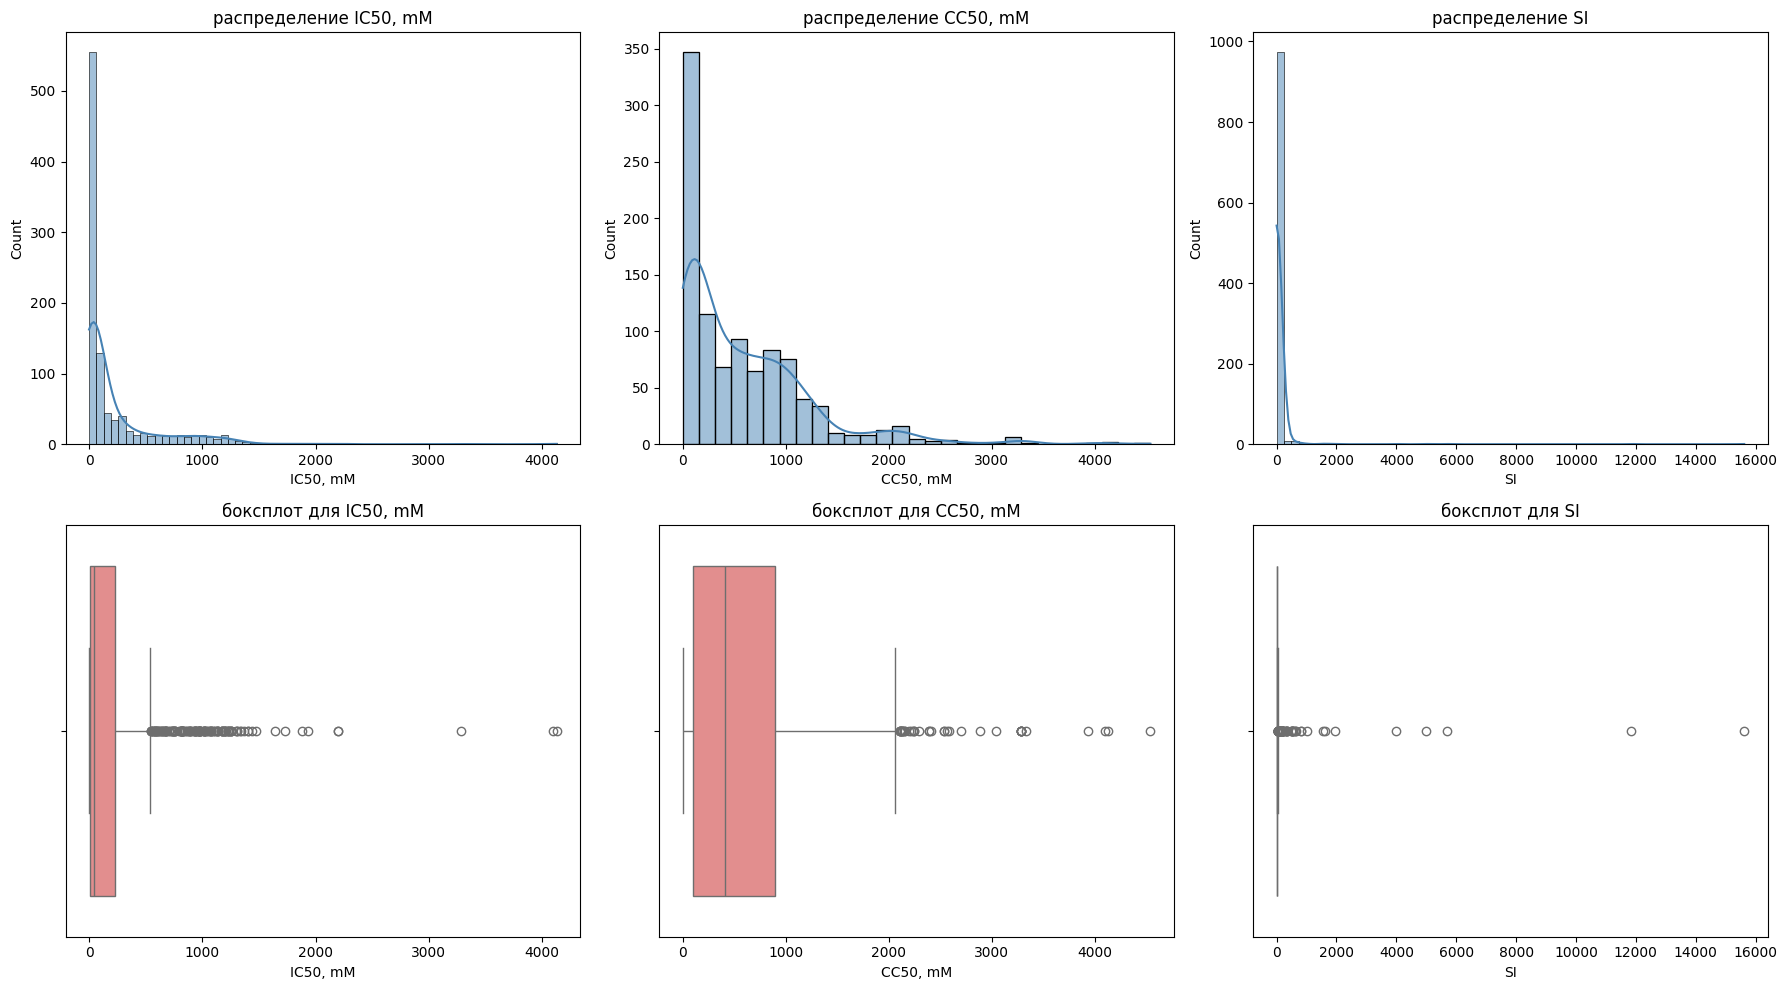

In [13]:
file_path = 'Данные_для_курсовои_Классическое_МО.xlsx'
df = pd.read_excel(file_path)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"размерность датасета: {df.shape}")
print("общая информация:")
df.info()

total_nans = df.isna().sum().sum()
print(f"общее количество пропущенных значений (NaN): {total_nans}")

targets = ['IC50, mM', 'CC50, mM', 'SI']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(targets):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'распределение {col}')
    sns.boxplot(x=df[col], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'боксплот для {col}')

plt.tight_layout()
plt.show()



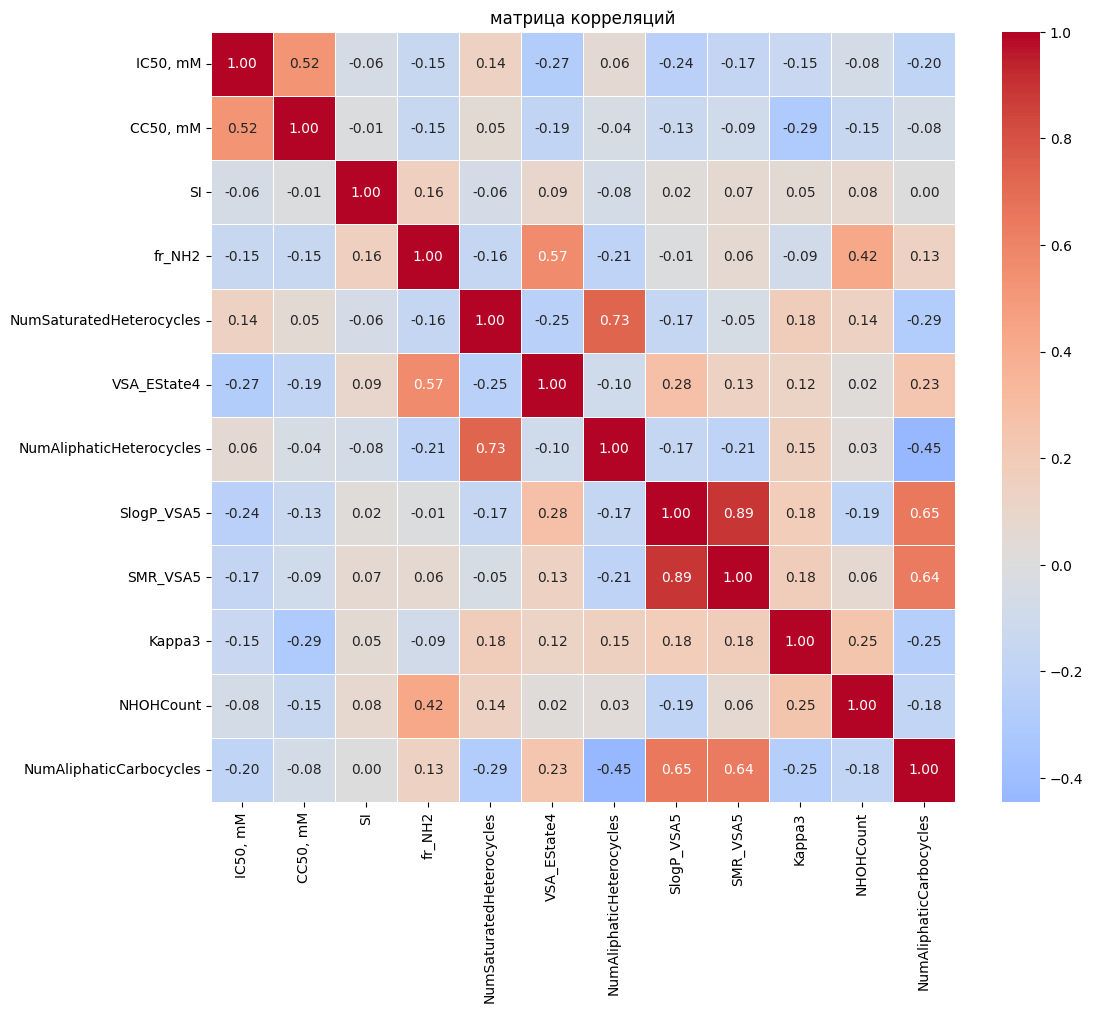

In [14]:
temp_pIC50 = -np.log10(df['IC50, mM'] + 1e-6)

numeric_df = df.select_dtypes(include=[np.number])
non_constant_cols = numeric_df.columns[numeric_df.std() > 0]
clean_numeric_df = numeric_df[non_constant_cols]

top_features = clean_numeric_df.corrwith(temp_pIC50).abs().sort_values(ascending=False).head(12).index
corr_subset = clean_numeric_df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=.5)
plt.title("матрица корреляций")
plt.show()

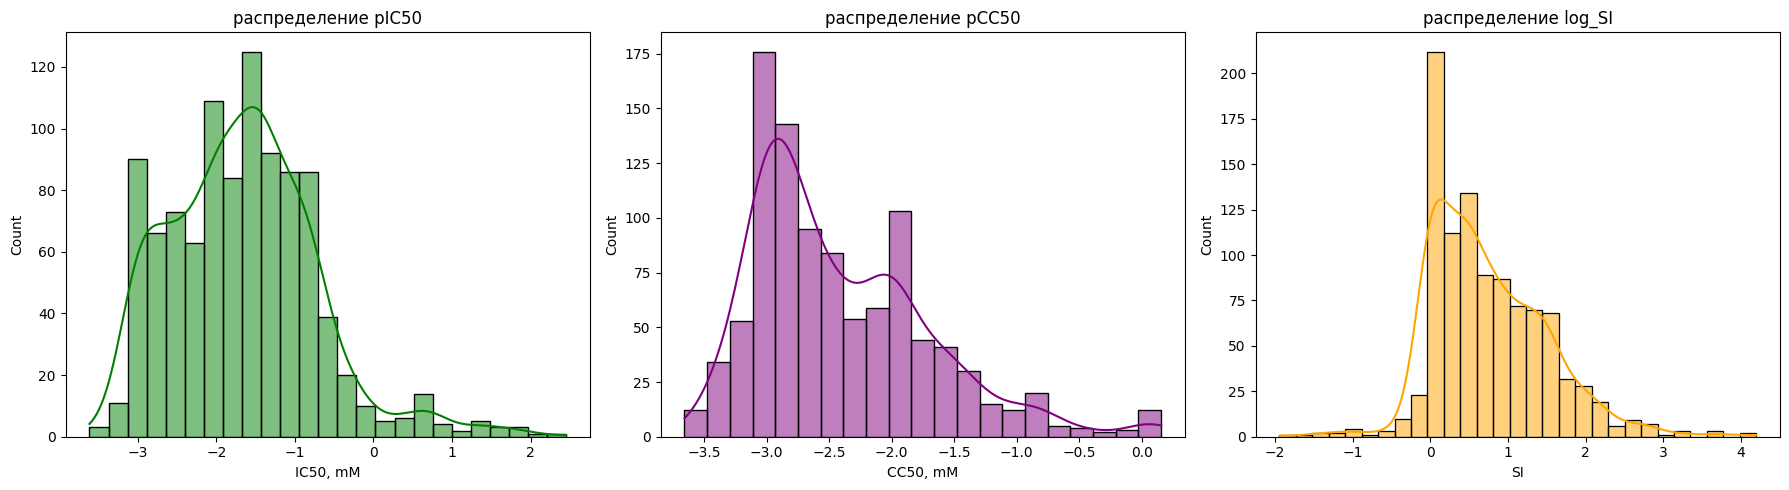

баланс классов (SI > 8):
класс 1 (SI > 8): 35.66%
класс 0 (SI <= 8): 64.34%
------------------------------
пропуски успешно заполнены.
итоги предобработки:
осталось признаков: 139


In [15]:
df['pIC50'] = -np.log10(df['IC50, mM'] + 1e-6)
df['pCC50'] = -np.log10(df['CC50, mM'] + 1e-6)
df['log_SI'] = np.log10(df['SI'] + 1e-6)

df['IC50_above_med'] = (df['IC50, mM'] > df['IC50, mM'].median()).astype(int)
df['CC50_above_med'] = (df['CC50, mM'] > df['CC50, mM'].median()).astype(int)
df['SI_above_med']   = (df['SI'] > df['SI'].median()).astype(int)
df['SI_above_8']     = (df['SI'] > 8).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(-np.log10(df['IC50, mM'] + 1e-6), kde=True, ax=axes[0], color='green').set_title('распределение pIC50')
sns.histplot(-np.log10(df['CC50, mM'] + 1e-6), kde=True, ax=axes[1], color='purple').set_title('распределение pCC50')
sns.histplot(np.log10(df['SI'] + 1e-6), kde=True, ax=axes[2], color='orange').set_title('распределение log_SI')
plt.tight_layout()
plt.show()

print("баланс классов (SI > 8):")
proportions = df['SI_above_8'].value_counts(normalize=True) * 100
print(f"класс 1 (SI > 8): {proportions[1]:.2f}%")
print(f"класс 0 (SI <= 8): {proportions[0]:.2f}%")
print("-" * 30)

target_cols = ['IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log_SI',
               'IC50_above_med', 'CC50_above_med', 'SI_above_med', 'SI_above_8']
features_raw = df.drop(columns=target_cols).select_dtypes(include=[np.number])

imputer = SimpleImputer(strategy='median')
features_imputed = imputer.fit_transform(features_raw)
features_raw = pd.DataFrame(features_imputed, columns=features_raw.columns, index=features_raw.index)

if features_raw.isnull().sum().sum() == 0:
    print("пропуски успешно заполнены.")

selector = VarianceThreshold(threshold=0.01)
selector.fit(features_raw)
features_var_names = features_raw.columns[selector.get_support()]
features_var = features_raw[features_var_names].copy()

def clip_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

features_cleaned = features_var.apply(clip_outliers)

corr_matrix = features_cleaned.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
features_final_names = [c for c in features_cleaned.columns if c not in to_drop]
features_final = features_cleaned[features_final_names]

df_cleaned = pd.concat([features_final, df[target_cols]], axis=1)

print("итоги предобработки:")
print(f"осталось признаков: {len(features_final_names)}")

# "чистый" датасет для дальнейшей работы
df_cleaned.to_csv('cleaned_data.csv', index=False)

ВЫВОДЫ: 


Обнаружено 36 пропущенных значений, которые были заполнены медианными значениями соответствующих признаков. Выбор медианы в качестве стратегии импутации обусловлен наличием асимметрии в распределениях дескрипторов, что делает среднее арифметическое менее устойчивым к выбросам.

Для снижения влияния аномальных наблюдений на обучение алгоритмов я применила метод ограничения выбросов по межквартильному размаху (IQR с коэффициентом 1.5). Данная процедура позволила уменьшить потенциальное искажающее воздействие экстремальных значений.

С целью сокращения признакового пространства и борьбы с мультиколлинеарностью были удалены константные признаки, а также сильно коррелирующие между собой столбцы (порог корреляции 0.9). В результате количество дескрипторов сократилось с 209 до 130.

При анализе баланса классов для задачи классификации SI > 8 мною зафиксирован умеренный дисбаланс: доля положительного класса составляет приблизительно 35.7%. Это обстоятельство потребует использования метрик, устойчивых к несбалансированным выборкам, – в частности, F₁-меры и площади под Precision-Recall кривой (PR-AUC).

Итоговый датасет сохранён без предварительного масштабирования признаков. Стандартизация будет осуществляться динамически внутри пайплайнов кросс-валидации, что исключает утечку информации из тестовой выборки в процесс обучения.

